In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from stylegan2_core import StyleGAN2Generator, LATENT_DIM

tf.random.set_seed(1)
np.random.seed(1)
gen = StyleGAN2Generator()


In [2]:
def generate_from_w(gen_model, w):
    batch_size = tf.shape(w)[0]
    x = tf.tile(gen_model.const_input, [batch_size, 1, 1, 1])
    for block in gen_model.blocks:
        x, rgb = block(x, w)
    return rgb


In [3]:
N = 500
z_samples = tf.random.normal((N, LATENT_DIM))
w_samples = gen.mapping(z_samples)
images = generate_from_w(gen, w_samples)


In [4]:
class SimpleFeatureExtractor(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.conv1 = tf.keras.layers.Conv2D(16, 3, strides=2, padding="same", activation="relu")
        self.conv2 = tf.keras.layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")
        self.pool = tf.keras.layers.GlobalAveragePooling2D()

    def call(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        return self.pool(x)

feature_extractor = SimpleFeatureExtractor()
_ = feature_extractor(images[:1])


In [5]:
brightness = tf.reduce_mean(images, axis=[1, 2, 3]).numpy()
labels = (brightness > np.median(brightness)).astype(int)
print("label balance:", labels.mean())


label balance: 0.5


In [6]:
svm = LinearSVC(C=1.0, max_iter=5000)
svm.fit(w_samples.numpy(), labels)
n_vec = svm.coef_[0]
n_vec = n_vec / np.linalg.norm(n_vec)
n_vec = tf.constant(n_vec, dtype=tf.float32)
print("direction vector norm:", float(tf.norm(n_vec)))


direction vector norm: 1.0


In [7]:
z_test = tf.random.normal((1, LATENT_DIM))
w_test = gen.mapping(z_test)
alphas = np.linspace(-3, 3, 13)

edited_images = []
for a in alphas:
    w_edit = w_test + a * n_vec[None, :]
    edited_images.append(generate_from_w(gen, w_edit)[0])
edited_images = tf.stack(edited_images)
orig_image = generate_from_w(gen, w_test)[0]


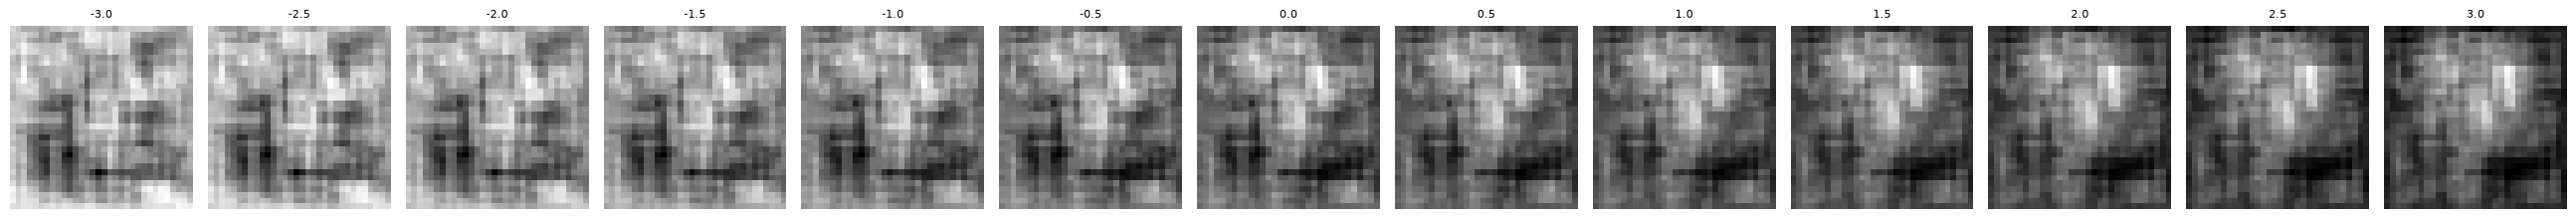

In [8]:
fig, axes = plt.subplots(1, len(alphas), figsize=(2 * len(alphas), 2.2))
for i, a in enumerate(alphas):
    axes[i].imshow((edited_images[i, ..., 0].numpy() + 1) / 2, cmap="gray")
    axes[i].set_title(f"{a:.1f}", fontsize=8)
    axes[i].axis("off")
plt.tight_layout()
plt.show()


In [9]:
orig_feat = feature_extractor(orig_image[None, ...])[0].numpy()
attribute_scores, identity_dists = [], []
for i, a in enumerate(alphas):
    w_edit = w_test + a * n_vec[None, :]
    attribute_scores.append(float(svm.decision_function(w_edit.numpy())[0]))
    edited_feat = feature_extractor(edited_images[i:i + 1])[0].numpy()
    cos_sim = np.dot(orig_feat, edited_feat) / (np.linalg.norm(orig_feat) * np.linalg.norm(edited_feat) + 1e-8)
    identity_dists.append(1 - cos_sim)


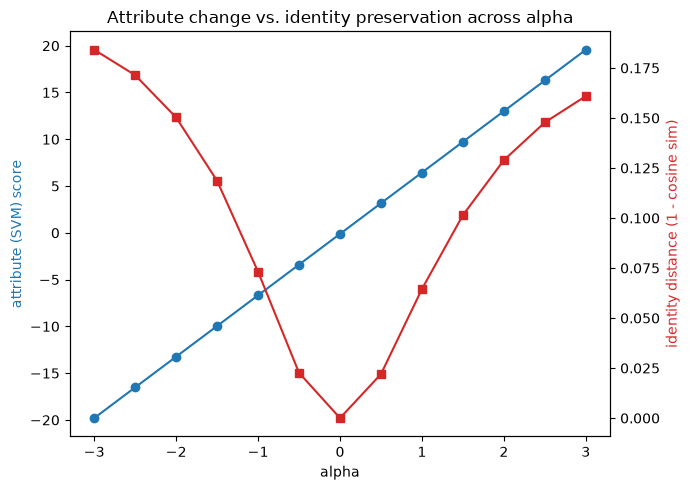

In [10]:
fig, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(alphas, attribute_scores, marker="o", color="tab:blue", label="attribute score")
ax1.set_xlabel("alpha")
ax1.set_ylabel("attribute (SVM) score", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(alphas, identity_dists, marker="s", color="tab:red", label="identity distance")
ax2.set_ylabel("identity distance (1 - cosine sim)", color="tab:red")
plt.title("Attribute change vs. identity preservation across alpha")
plt.tight_layout()
plt.show()
